<a href="https://colab.research.google.com/github/saitharun16/-AI-Powered-Plant-Health-and-Soil-Suitability-Analyses/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

In [ ]:
!pip install tensorflow

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="uohy9QmufUiPb8wshsKf")

project = rf.workspace("crop-recomendation-wfyn7").project("soil-type-ladmq")

dataset = project.version("6").download("folder")

print(f"Dataset downloaded to: {dataset.location}")


In [4]:
import os

def count_images(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len([file for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return count

data_dir = "/content/Soil-Type-6"

# Paths
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
test_dir = os.path.join(data_dir, "test")

# Count images
num_train = count_images(train_dir)
num_valid = count_images(valid_dir)
num_test = count_images(test_dir)

print(f"Number of images in train set: {num_train}")
print(f"Number of images in validation set: {num_valid}")
print(f"Number of images in test set: {num_test}")


Number of images in train set: 9582
Number of images in validation set: 1386
Number of images in test set: 682


In [6]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Define dataset paths
data_dir = "/content/Soil-Type-6"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
test_dir = os.path.join(data_dir, "test")

# Image size and batch size
img_size = (128, 128)
batch_size = 32

# Data augmentation and generators
gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True, rotation_range=15)
train_gen = gen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
valid_gen = gen.flow_from_directory(valid_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
test_gen = gen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),# o/p

    Flatten(),#o/p
    Dense(128, activation='relu'),
    #o/p
    Dropout(0.5),#o/p
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_gen, validation_data=valid_gen, epochs=20)

test_loss, test_acc = model.evaluate(test_gen)

print(f"Test Accuracy: {test_acc:.2f}")

Found 9582 images belonging to 11 classes.
Found 1386 images belonging to 11 classes.
Found 682 images belonging to 11 classes.
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 61s 190ms/step - accuracy: 0.5455 - loss: 1.3281 - val_accuracy: 0.7367 - val_loss: 0.6653
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 220ms/step - accuracy: 0.7577 - loss: 0.7152 - val_accuracy: 0.7619 - val_loss: 0.6453
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 55s 183ms/step - accuracy: 0.8010 - loss: 0.6122 - val_accuracy: 0.8355 - val_loss: 0.4939
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - accuracy: 0.8244 - loss: 0.5401 - val_accuracy: 0.8694 - val_loss: 0.4115
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 172ms/step - accuracy: 0.8326 - loss: 0.5203 - val_accuracy: 0.8730 - val_loss: 0.4064
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - accuracy: 0.8520 - loss: 0.4571 - val_accuracy: 0.8961 - val_loss: 0.3670
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 54s 181ms/step - accuracy: 0.8553 - loss: 0.41

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step

Classification Report:
              precision    recall  f1-score   support

    alluvial       0.68      0.88      0.77        32
       black       0.97      0.99      0.98       270
      cinder       0.92      0.96      0.94        79
        clay       0.86      0.60      0.71        20
    laterite       0.90      0.93      0.91        86
       loamy       0.00      0.00      0.00         1
        peat       0.88      0.93      0.90        71
         red       0.89      0.77      0.83        31
       sandy       0.00      0.00      0.00         4
  sandy_loam       0.00      0.00      0.00         2
      yellow       1.00      0.92      0.96        86

    accuracy                           0.93       682
   macro avg       0.64      0.63      0.64       682
weighted avg       0.92      0.93      0.92       682


Classification Report (Table Format):
              precision    recall  f1-score    support
alluvial       0.682927  0.8

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


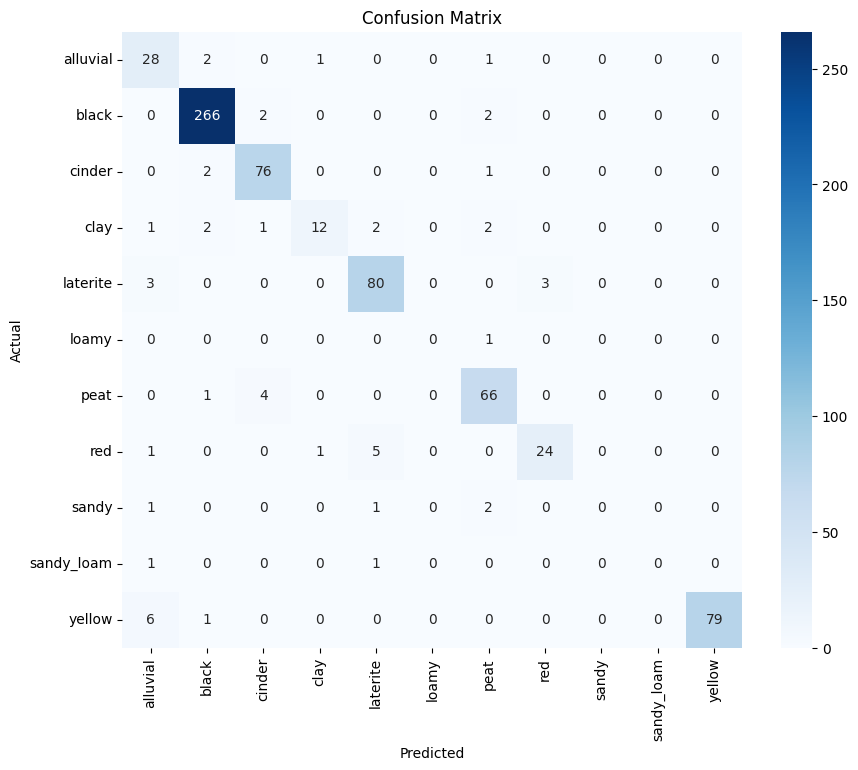

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Predictions
predictions = model.predict(test_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Print classification report
print("\nClassification Report:")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# Convert report to table format
import pandas as pd
report_dict = classification_report(true_classes, predicted_classes, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("\nClassification Report (Table Format):")
print(report_df)

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


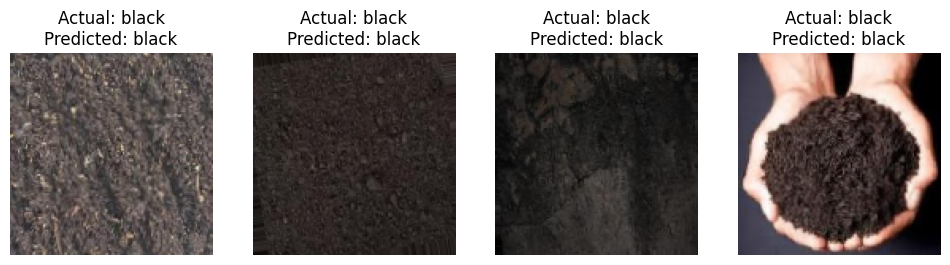

In [9]:
# Display 4 sample predictions
num_samples = 4
sample_images, sample_labels = next(test_gen)
sample_preds = model.predict(sample_images[:num_samples])
predicted_labels = [class_labels[np.argmax(pred)] for pred in sample_preds]
actual_labels = [class_labels[np.argmax(label)] for label in sample_labels[:num_samples]]

plt.figure(figsize=(12, 6))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i])
    plt.axis("off")
    plt.title(f"Actual: {actual_labels[i]}\nPredicted: {predicted_labels[i]}")
plt.show()

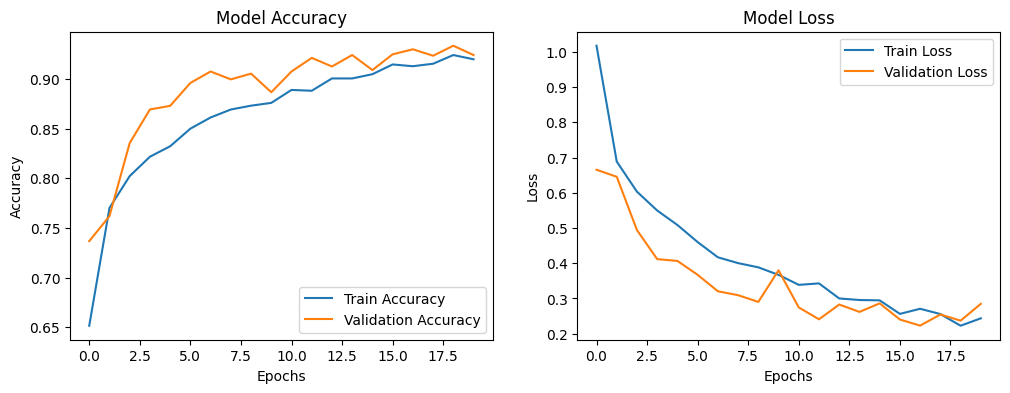

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

plt.show()


In [11]:
model.save("soil_model.h5")

In [12]:
model.save("soil_model.keras")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_soil_type(image_path, model, class_indices):
    """Predict the class of a given soil image using the trained CNN model."""
    img_size = (128, 128)  # Match training size
    img = image.load_img(image_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predicting the class
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)

    # Get class labels from the generator's class indices
    class_labels = {v: k for k, v in class_indices.items()}  # Reverse mapping
    predicted_class = class_labels[predicted_index]

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()

    return predicted_class

test_image_path = "/content/red-dirt.jpg"
predicted_class = predict_soil_type(test_image_path, model, train_gen.class_indices)
print("Predicted Soil Type:", predicted_class)


In [13]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

data_dir = "/content/Soil-Type-6"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
test_dir = os.path.join(data_dir, "test")

img_size = (128, 128)
batch_size = 16

gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True, rotation_range=15)
train_gen = gen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
valid_gen = gen.flow_from_directory(valid_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
test_gen = gen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation="softmax")
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_gen, validation_data=valid_gen, epochs=20)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.2f}")


Found 9582 images belonging to 11 classes.
Found 1386 images belonging to 11 classes.
Found 682 images belonging to 11 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


599/599 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.3881 - loss: 1.8469 - val_accuracy: 0.6176 - val_loss: 1.1654
Epoch 2/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 63s 106ms/step - accuracy: 0.6035 - loss: 1.2084 - val_accuracy: 0.6789 - val_loss: 0.9536
Epoch 3/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 63s 105ms/step - accuracy: 0.6691 - loss: 1.0151 - val_accuracy: 0.7367 - val_loss: 0.8377
Epoch 4/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 63s 106ms/step - accuracy: 0.7050 - loss: 0.9045 - val_accuracy: 0.7518 - val_loss: 0.7568
Epoch 5/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 61s 102ms/step - accuracy: 0.7180 - loss: 0.8328 - val_accuracy: 0.7821 - val_loss: 0.6815
Epoch 6/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 61s 102ms/step - accuracy: 0.7512 - loss: 0.7652 - val_accuracy: 0.7886 - val_loss: 0.6334
Epoch 7/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 59s 99ms/step - accuracy: 0.7640 - loss: 0.7330 - val_accuracy: 0.8001 - val_loss: 0.6082
Epoch 8/20
599/599 ━━━━━━━━━━━━━━━━━━━━ 60s 100ms/step - accuracy: 0.7766 - loss: 0.6825 - val_

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step

Classification Report:
              precision    recall  f1-score   support

    alluvial       0.76      0.69      0.72        32
       black       0.92      0.97      0.95       270
      cinder       0.86      0.94      0.90        79
        clay       0.78      0.70      0.74        20
    laterite       0.84      0.88      0.86        86
       loamy       0.00      0.00      0.00         1
        peat       0.81      0.79      0.80        71
         red       0.91      0.65      0.75        31
       sandy       0.00      0.00      0.00         4
  sandy_loam       0.00      0.00      0.00         2
      yellow       0.93      0.90      0.91        86

    accuracy                           0.88       682
   macro avg       0.62      0.59      0.60       682
weighted avg       0.87      0.88      0.87       682


Classification Report (Table Format):
              precision    recall  f1-score     support
alluvial       0.758621  0.

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


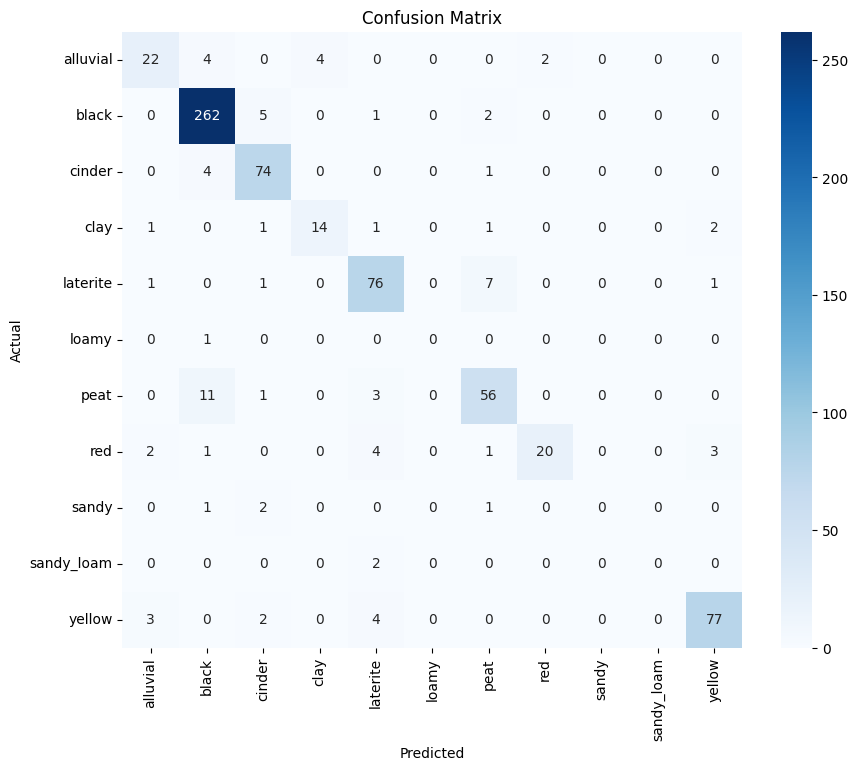

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
# Predictions
predictions = model.predict(test_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Print classification report
print("\nClassification Report:")
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# Convert report to table format
report_dict = classification_report(true_classes, predicted_classes, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("\nClassification Report (Table Format):")
print(report_df)

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


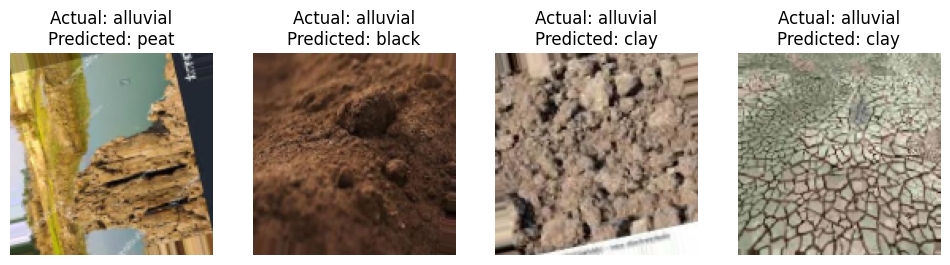

In [15]:
# Display 4 sample predictions
num_samples = 4
sample_images, sample_labels = next(test_gen)
sample_preds = model.predict(sample_images[:num_samples])
predicted_labels = [class_labels[np.argmax(pred)] for pred in sample_preds]
actual_labels = [class_labels[np.argmax(label)] for label in sample_labels[:num_samples]]

plt.figure(figsize=(12, 6))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i])
    plt.axis("off")
    plt.title(f"Actual: {actual_labels[i]}\nPredicted: {predicted_labels[i]}")
plt.show()

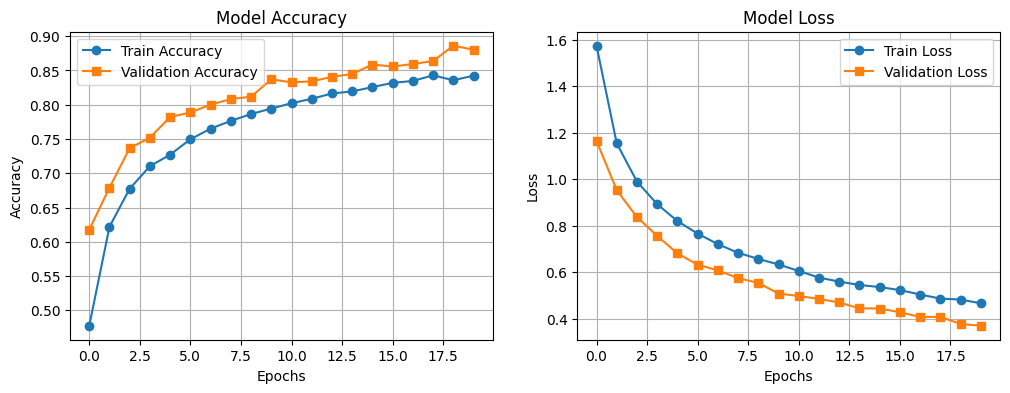

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss", marker="o")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.grid(True)

plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_image(model, img_path, class_indices):
    img_size = (128, 128)
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]

    # Get class labels from the generator's class indices
    class_labels = {v: k for k, v in class_indices.items()}  # Reverse mapping
    predicted_label = class_labels[predicted_class]

    # Display the image and prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

    return predicted_label

image_path = "/content/hands-holding-compost.jpg"
predicted_label = predict_image(model, image_path, train_gen.class_indices)
print(f"Predicted Class: {predicted_label}")


In [19]:
model.save("soil_modelVGG.h5")

In [20]:
model.save("soil_modelVGG.keras")
